# Chapter 1: Deep Learning

In the last chapter we saw how we can automatically generate text using Markov chains. We also saw that one of the problems with this approach is that it is impractical to capture long term dependencies due to combinatorial explosion of the number of states. In this chapter we will see the basis that will enable to solve this and other problems. Why if instead of writing the algorithm to solve the problem we write a learning strategy that can learn to solve problems from data? The method we start here is inspired in how our brain process information.

<img src="./neuron.png" alt="Neuron" width="800" height="400">

## A single neuron

Let's start simple and later we will see how we can simulate a neuron to learn from data.

Consider the function $f(x) = w \cdot x + b$. How can we automatically find the values of $w$ and $b$ that make $f(2) = 5$? Let's start with $w = 1$ and $b = 1$ and see how we can improve from there.

In [12]:
# our input
x = 2
# our expected value
y = 5

# our function parameters
w = 1
b = 1

# our function
def f(x):
    return w * x + b


# let's test it
o = f(x)

print(o)

3


In [13]:
# the error of our prediction
error = y - o

print(error)

2


Computing our error we get 2. If the predicted value is higher than the expected value we will get a negative error. We don't want that since the error is the distance between the expected and the predicted value and we want positive distances. We can solve this by simple squaring the error as $error = (y - o) ^ 2$. This way we will always get a positive error and the error will be higher the more distant the predicted value is from the expected value.

In [14]:
error_sqr = (y - o) ** 2

print(error_sqr)

4


Now let's plot the error function and see where our predicted value error lies in this function.

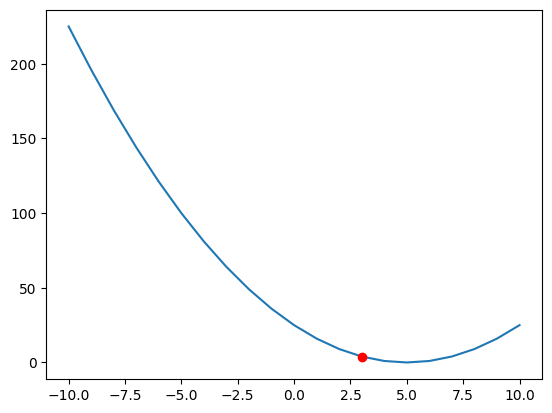

In [15]:
import matplotlib.pyplot as plt

# plotting the error function
e = [(y - i) ** 2 for i in range(-10, 11)]
plt.plot(range(-10, 11), e, zorder=1)

# plotting our predicted value error
plt.scatter(o, error_sqr, color='red', zorder=2)

plt.show()

If we have a way to discover how to change our values $w$ and $b$ to make the function give a function output closer to the expected value. By doing that we will decrease our error and we will be able to found the function we want. In this sense reducing the error function is the same as finding the function we want. The good news is that we can borrow the concepts of derivative from calculus to solve this. The derivative of a function gives us the slope of the function at a given point. This slope shows us how the function changes if we change our inputs. You can find more about derivatives [here](https://www.khanacademy.org/math/differential-calculus/dc-diff-intro/dc-diff-calc-intro/v/newton-leibniz-and-usain-bolt).

The derivative of our error function as it is an exponential is defined as $n \cdot x^{n-1}$ where $n$ is the exponent and $x$ is the base. In our case the base is also a function and to derive a function of a function we need to apply the chain rule that is defined as $f(g(x))' = f'(g(x)) \cdot g'(x)$. In our case $f(x) = x^2$ and $g(x) = y - o$. So we have that the derivative of our error function is $2(y - o) \cdot d(y - o)$. Since $y$ is a constant and in this case the output is our variable and the derivative of a variable is 1 we have that $d(y - o) = -1$. So we have that the derivative of our error function is $-2(y - o)$.

Let's see how this derivative looks like in our error function plot.

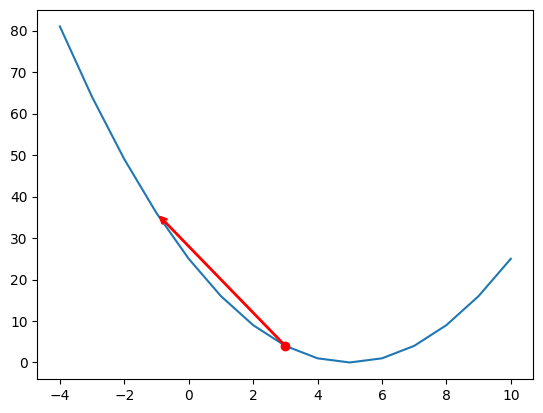

In [16]:
# our error derivative
d_error = -2 * (y - o)

# plotting the error function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)

# plotting the expected value error
plt.scatter(o, error_sqr, color='red', zorder=2)

# drawing an arrow to show the direction of the change of the error function from the predicted value
plt.annotate(
    "",
    xy=(o + d_error, (y - (o + d_error)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='red'),
)

plt.show()

The derivative in this case is showing how to increase the error function. This change direction from a point is called the gradient. Since the gradient is showing us the direction of steepest increase in our function, we can take the opposite direction to get the steepest decrease in our function.

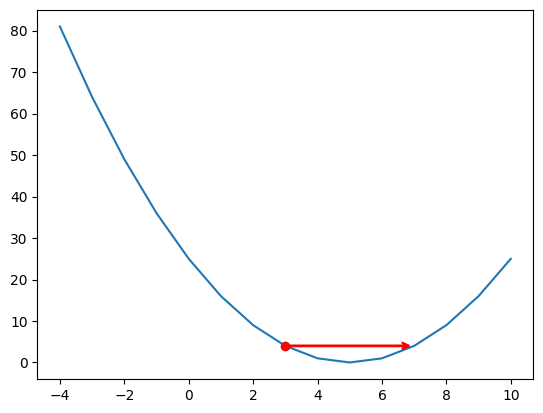

In [17]:
# our error derivative
d_error = -2 * (y - o)

# plotting the error function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)

# plotting the expected value error
plt.scatter(o, error_sqr, color='red', zorder=2)

# multiplying the gradient by -1 to get the direction of steepest decrease in our function
plt.annotate(
    "",
    xy=(o - d_error, (y - (o - d_error)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='red'),
)

plt.show()

We took a large jump in the direction of decreasing our function. However, this throws us far away from the expected value. This can cause a problem of constantly missing the target and never minimizing our error function.

To avoid this we can take smaller steps in the direction of decreasing our function leading it to convergence.

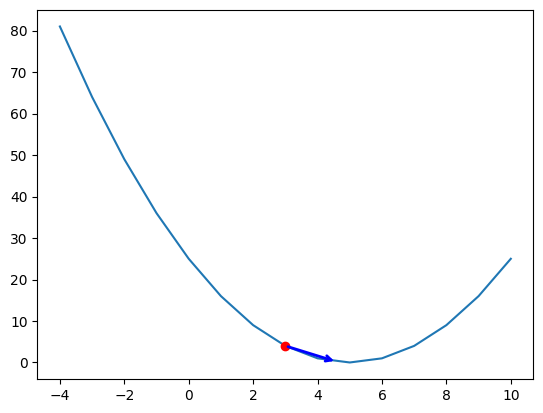

In [18]:
# our error derivative
d_error = -2 * (y - o)

# reducing the step size to get closer to the expected value
d_error *= 0.4

# plotting the error function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)

# plotting the expected value error
plt.scatter(o, error_sqr, color='red', zorder=2)

# multiplying the gradient by -1 to get the direction of steepest decrease in our function
plt.annotate(
    "",
    xy=(o - d_error, (y - (o - d_error)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='blue'),
)

plt.show()

The name of this optimization technique is gradient descent and we can use it to learn the right parameters of our function. The problem is that the gradient is defined for functions with only one variable. And we have $w$ and $b$ to change. To solve this we can compute the partial derivatives instead of the total derivative. The partial derivative of a function with respect to a variable computes how a function changes if we change only that variable. Computing it is similar to computing the total derivative but we consider the other values as constants. More about partial derivatives [here](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivative-and-gradient-articles/a/introduction-to-partial-derivatives).

### The chain rule

We know that we partial derivatives we can compute the change in our variables. But how we can compute the partial derivative of our error function with respect to $w$? We know how to compute how the error function changes when the output changes. But how can we compute how the error changes if we change $w$? We ca use the chain rule to solve this:

$$ \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} $$

This formula can be frightening at first glance. But what it is telling us is that the derivative of a function is computed by mutiplying the local derivatives of a function at each step until we reach our variables we want to change. In our case we have two steps. The first step is computing how the error changes if we change the output and the second step is computing how the output changes if we change $w$. So we have that:

$$ \frac{d(error)}{dw} = \frac{d(error)}{do} \cdot \frac{do}{dw} $$

We have to do the same with $b$:

$$ \frac{d(error)}{db} = \frac{d(error)}{do} \cdot \frac{do}{db} $$

The good part of this is that we are just multiplying two numbers. And that's it. By computing the gradient of our error function and adding its negative to our variables we can reduce our error and get closer to the expected value. Let's compute those derivatives:

$$ \frac{d(error)}{dw} = \frac{d(error)}{do} \cdot \frac{do}{dw} $$

Let's consider that our output is $o$. So we have that:

$$ \frac{d(error)}{dw} = (y - o)'^2 $$

Applying the chain rule we have that:

$$ \frac{d(error)}{dw} = 2(y - o) * (y - o)' $$

The y is a constant and its derivative is 0. Let's replace o in the formula to compute its derivative with respect to $w$:

$$ \frac{d(error)}{dw} = 2(y - o) * (0 - (wx + b)') $$

The derivative of the sum is the sum of the derivatives and since b is a constant its derivative is 0. The derivative of a product is defined as $d(uv) = u'v + uv'$. So we have that:

$$ \frac{d(error)}{dw} = 2(y - o) * (0 - (w'x + w'x + 0)) $$

Since $w$ is our variable its derivative is 1 and $x$ is constant so its derivative is 0:

$$ \frac{d(error)}{dw} = 2(y - o) * (0 - (x + 0)) $$

Simplifying we have that:

$$ \frac{d(error)}{dw} = -2(y - o) * x $$

Doing the same for $b$ (in fast forward):

$$ \frac{d(error)}{db} = -2(y - o) * 1 $$

Now that we have the gradients of our function we can compute them and update our variables to get closer to the expected value.

In [19]:
# our input
x = 2
# our expected value
y = 5

# our function parameters
w = 1
b = 1

# our function but with the parameters as arguments
def f(x, w, b):
    return w * x + b


# let's test it
o = f(x, w, b)
print('Output:', o)

error = (y - o) ** 2
print('Error:', error)

# Gradient for w
dw = -2 * (y - o) * x
# Gradient for b
db = -2 * (y - o) * 1
print('dw:', dw, 'db:', db)

# adding a small amount of the negative gradient to our variables
a = 0.01

# adding the negative is the same as subtracting
w -= a * dw
b -= a * db

# now testing again
o = f(x, w, b)
print('Output after update:', o)
error = (y - o) ** 2
print('Error after update:', error)

Output: 3
Error: 4
dw: -8 db: -4
Output after update: 3.2
Error after update: 3.2399999999999993


Our output is now closer to the expected value and our error is smaller. Let's repeat this process a few times and see how the error drops.

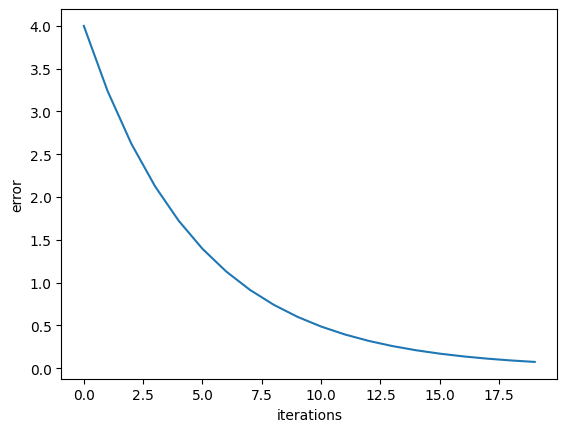

In [20]:
x = 2
y = 5

w = 1
b = 1

def f(x, w, b):
    return w * x + b

# scale of our gradients
a = 0.01

error_history = []

iterations = 20
for _ in range(iterations):
    o = f(x, w, b)
    error_sqr = (y - o) ** 2
    error_history.append(error_sqr)

    # Gradient for w
    dw = -2 * (y - o) * x
    # Gradient for b
    db = -2 * (y - o) * 1

    # gradient descent step
    w -= a * dw
    b -= a * db


plt.plot(error_history)
plt.xlabel('iterations')
plt.ylabel('error')
plt.show()

Our error drops to almost 0 after 20 iterations. Let's see the final output of our function with the learned parameters.

In [21]:
print(f'Learned parameters: w={w:.2f}, b={b:.2f}')
print(f'Final output: {f(x, w, b):.2f}')

Learned parameters: w=1.70, b=1.35
Final output: 4.76


Our approach works for one values. But if we have multiple target values? For example, if we have a dataset of 50 points and we want to learn the parameters of a function that fits those points. Instead we compute the average error over the dataset. The gradient of the average error can be computed by averaging the gradients of the error for each point in the dataset. This way we can learn the parameters of a function that fits our dataset. Let's see how this works in practice.

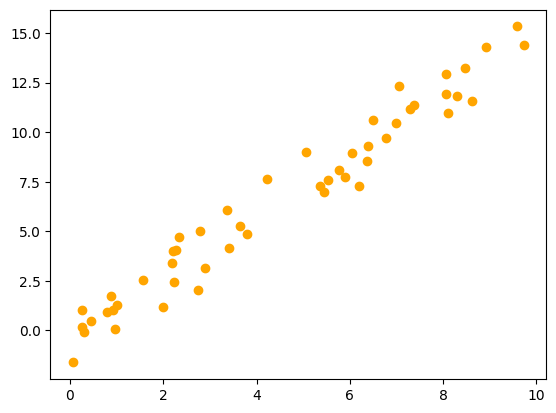

In [22]:
import random

random.seed(42)

# random generating a dataset of 50 points
sx = [random.random() * 10 for _ in range(50)]
sy = [random.normalvariate() for _ in range(50)]
sy = [1.5 * x + y for x, y in zip(sx, sy)]

plt.scatter(sx, sy, color='orange', zorder=2)
plt.show()

We generated 50 points in a linear distribution with some noise. Since our function describes a line we can find the parameters that fits best this line. Let's start with $w = 0$ and $b = 5$ and see how the line fits our data.

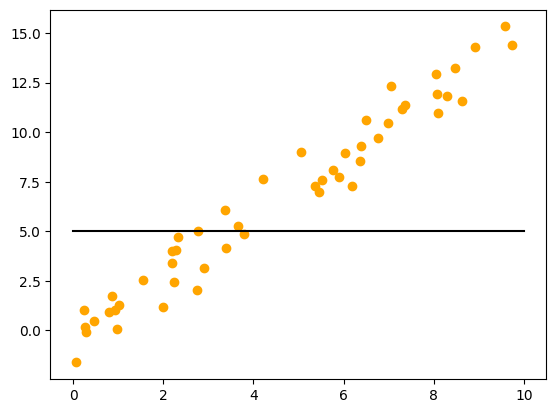

In [23]:
# plotting the data
plt.scatter(sx, sy, color='orange', zorder=1)


# our data parameters
w = 0
b = 5

# plotting our line
line = [f(i, w, b) for i in range(11)]

plt.plot(range(11), line, color='black', zorder=2)
plt.show()

The starting line doesn't fit our data. Now let's apply gradient descent to learn the parameters of the line that best fits our data. We will repeat this process for 400 iterations and see how the line fits our data.

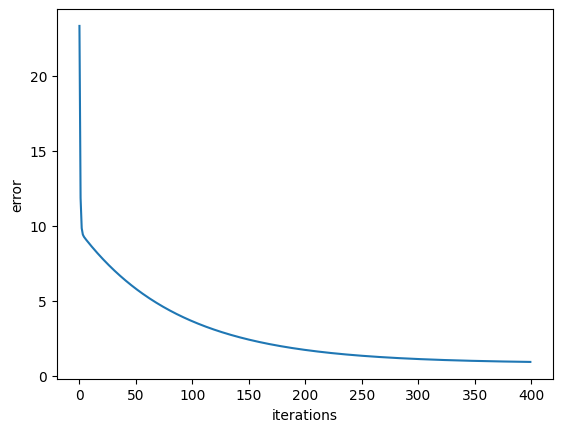

Learned parameters: w=1.45, b=0.18


In [24]:
w = 0
b = 5

a = 0.01

iterations = 400
error_history = []

for _ in range(iterations):
    # accumulated gradients
    gw = 0
    gb = 0
    # epoch loss
    el = []
    for x1, y1 in zip(sx, sy):
        o = f(x1, w, b)
        error_sqr = (y1 - o) ** 2
        el.append(error_sqr)

        # Gradient for w
        gw += -2 * (y1 - o) * x1

        # Gradient for b
        gb += -2 * (y1 - o)

    # scale by the number of points in the dataset
    w -= a * gw / len(sx)
    b -= a * gb / len(sx)

    error_history.append(sum(el) / len(el))

plt.plot(error_history)
plt.xlabel('iterations')
plt.ylabel('error')
plt.show()

print(f'Learned parameters: w={w:.2f}, b={b:.2f}')

One of the indicators of the success of our approach is that the error is going down and that means that we are close to our objective.

Now let's see how the line with the learned parameters fits our data.

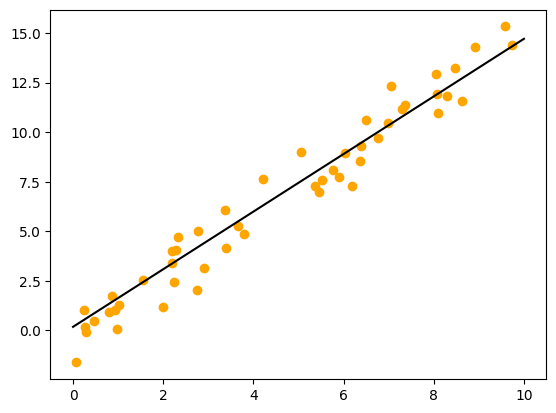

In [25]:
plt.scatter(sx, sy, color='orange', zorder=1)

line = [f(i, w, b) for i in range(11)]

plt.plot(range(11), line, color='black', zorder=2)
plt.show()

The learned function fits the date better than the initial function. This task is also know as linear regression and it is one of the most basic tasks in machine learning. In this case, our line have oly one dimension. Now let's extend this technique to multidimensional data.

## The Perceptron

Remember when we discussed simulating a neuron in the beginning of this chapter? Biological neurons receive multiple inputs from other neurons, weight then and emits an activation signal. We will simulate this behaviour by having a weighted sum of the inputs and then adding a constant. This is the same as our linear function but with more inputs. This model is called Perceptron. The input values are multiplied by weights, and then we add a constant called bias.

Let's build a Perceptron with two inputs. Also, let's create a class to better organize this model.

In [26]:
class Perceptron:
    def __init__(self):
        # weights
        self.w1 = 0
        self.w2 = 0

        # bias
        self.b = 0

    def forward(self, x1, x2):
        # weighted sum of the inputs plus the bias
        return self.w1 * x1 + self.w2 * x2 + self.b

    def backward(self, x1, x2, y, o):
        # a function to compute the gradients with respect to each parameter
        dw1 = -2 * (y - o) * x1
        dw2 = -2 * (y - o) * x2
        db = -2 * (y - o)
        return dw1, dw2, db

Now let's train this perceptron in the logical AND function. The AND function takes two binary inputs and returns 1 if both inputs are 1 and 0 otherwise:

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | 1 |

Also, let's rename some variables to adapt to the names used in machine learning. The number of iterations the model will be trained is called epochs. And the scale of the gradients is called learning rate since it controls how much we are learning in each step. Also, the error of the model is called loss and the function that computes it is called loss function.

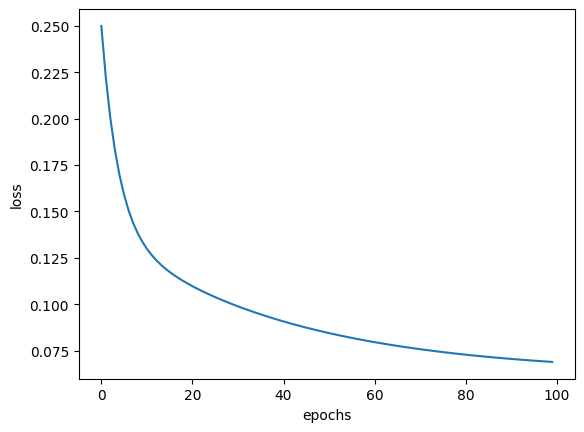

In [27]:
# inputs from AND truth table
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

# expected outputs from AND truth table
y = [0, 0, 0, 1]

# learning rate
lr = 0.01
# our model
perceptron = Perceptron()

epochs = 100

# loss history
lh = []
for _ in range(epochs):
    # accumulated gradients
    gw1 = 0
    gw2 = 0
    gb = 0
    # epoch loss
    el = []
    for (x1, x2), y1 in zip(x, y):
        o = perceptron.forward(x1, x2)
        loss = (y1 - o) ** 2
        el.append(loss)

        # gradients for each parameter
        dw1, dw2, db = perceptron.backward(x1, x2, y1, o)

        gw1 += dw1
        gw2 += dw2
        gb += db

    perceptron.w1 -= a * gw1
    perceptron.w2 -= a * gw2
    perceptron.b -= a * gb
    lh.append(sum(el) / len(el))


plt.plot(lh)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

Our loss goes down. Now let's see outputs of the model.

In [28]:
for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0 0 -> -0.1224
0 1 -> 0.2700
1 0 -> 0.2700
1 1 -> 0.6624


The output of the model is -0.12 when both inputs are 0 and 0.27 when only one of the inputs is 1. When both inputs are 1 the output is 0.66. Whe can see by those values that the model is struggling to learn the and function. Debugging neural model is ofter a difficult task. But visualizing the data and how the model is learning can help us to understand what is going on. Let's plot the data and the model parameters to see what is happening.

While having two input variables makes a two dimensional input, we actually need three dimensions to plot the data corresponding to the expected output. In this case, instead of modeling a line, our model is modeling a plane.

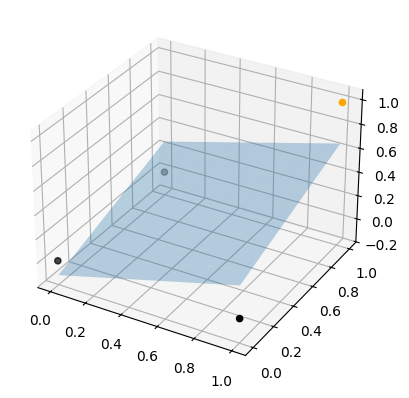

In [29]:
import numpy as np

ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 0, 1], [0, 1, 0], [0, 0, 0], color='black')
ax.scatter([1], [1], [1], color='orange')

# create grid
x = np.linspace(0, 1, 10)
y = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, y)

# plane equation: w1*x + w2*y + b = z
Z = perceptron.w1 * X + perceptron.w2 * Y + perceptron.b

ax.plot_surface(X, Y, Z, alpha=0.3)
plt.show()

We can see in this plot that the model can't increase the output for the point (1, 1) to be 1 without decreasing the output for (0, 0). To solve this we need to apply a non-linear function to model the data as we expect. One of those functions is the sigmoid function defined as:

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

Let's implement this function:

In [30]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

Now we have our function. We can apply it at the end of our perceptron computation to get a non-linear output. This is called an activation function.



In [31]:
class Perceptron:
    def __init__(self):
        self.w1 = 0
        self.w2 = 0
        self.b = 0

    def forward(self, x1, x2):
        h = self.w1 * x1 + self.w2 * x2 + self.b
        # sigmoid activation function
        return sigmoid(h)

We need now to compute the gradient of our loss function but with the sigmoid function applied to the output.

Let's start with our output:

$$ h = w_1x_1 + w_2x_2 + b $$
$$ o = \sigma(h) $$

Now we can compute the loss function:

$$ loss = (y - o) ^ 2 $$

Let's compute the derivative with respect to w_1 and then expand it to the other parameters:

$$ \frac{d loss}{dw_1} = (y - o) ^ 2$$

Applying the chain rule we have that:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot (y - o)'$$

Expanding the derivative of the output we have that:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot (0 - \sigma(h)') $$

Now we need to compute the derivative of the sigmoid function to keep applying the chain rule:

$$ \frac{d\sigma}{dx} = \frac{1}{1 + e^{-x}} $$

First applying the quotient rule:

$$ \frac{d\sigma}{dx} = \frac{(1)'(1 + e^{-x}) - (1)(1 + e^{-x})'}{(1 + e^{-x})^2} $$

Simplifying:

$$ \frac{d\sigma}{dx} = \frac{ e^{-x} }{(1 + e^{-x})(1 + e^{-x})} $$

Now we can rewrite this as:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ e^{-x} }{(1 + e^{-x})} $$

Now with a trick of adding zero to the numerator (1 - 1):

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ (1 + e^{-x}) - 1}{(1 + e^{-x})} $$

Rewriting the fractions:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ (1 + e^{-x})}{(1 + e^{-x})} - \frac{ 1 }{(1 + e^{-x})} $$

Replacing the one:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot 1 - \frac{ 1 }{(1 + e^{-x})} $$

Now look what we have:

$$ \frac{d\sigma}{dx} = \sigma(x) \cdot (1 - \sigma(x)) $$

The derivative of the sigmoid is a simple function. That's one of the reasons of choosing it as our activation function. Now we can apply the chain rule once more and compute the derivatives:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -\sigma(h) \cdot (1 - (\sigma(h)) * h' $$

Remember that $ o = \sigma(h) $:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o \cdot (1 - o) * h' $$

Replacing h:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o (1 - o) \cdot (w_1x_1 + w_2x_2 + b)' $$

From here we have the same derivative as before for the linear part:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o (1 - o) \cdot x_1 $$

$$ \frac{d loss}{dw_2} = 2(y - o) \cdot -o (1 - o) \cdot x_2 $$

$$ \frac{d loss}{db} = 2(y - o) \cdot -o (1 - o) $$

Now we can implement our backward function with the new gradients.


In [32]:
def backward(_, x1, x2, y, o):
    dw1 = 2 * (y - o) * (- o * (1 - o) * x1)
    dw2 = 2 * (y - o) * (- o * (1 - o) * x2)
    db = 2 * (y - o) * (- o * (1 - o))
    return dw1, dw2, db

Perceptron.backward = backward

Also, let's put the training conde into a function.

In [33]:
def train(model, x, y, lr, epochs):
    lh = []
    for _ in range(epochs):
        gw1 = 0
        gw2 = 0
        gb = 0
        el = []
        for (x1, x2), y1 in zip(x, y):
            o = model.forward(x1, x2)
            error_sqr = (y1 - o) ** 2
            el.append(error_sqr)

            dw1, dw2, db = model.backward(x1, x2, y1, o)

            gw1 += dw1
            gw2 += dw2
            gb += db

        lh.append(sum(el) / len(el))
        model.w1 -= lr * gw1
        model.w2 -= lr * gw2
        model.b -= lr * gb

    plt.plot(lh)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.show()

Training again with the new perceptron:

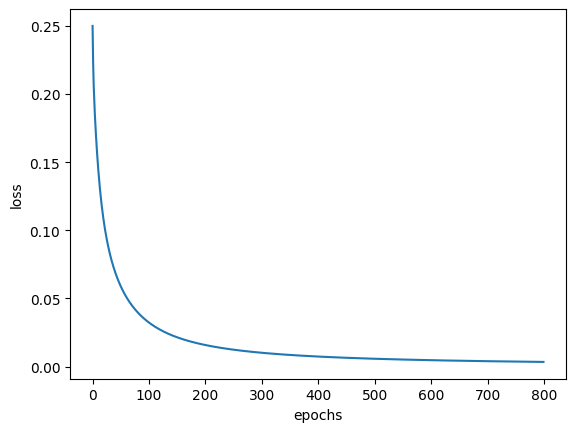

In [34]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 0, 0, 1]

a = 0.5

perceptron = Perceptron()

train(perceptron, x, y, a, 800)

And now we can test the outputs of the model.

In [35]:
print('w1:', perceptron.w1, 'w2:', perceptron.w2, 'b:', perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

w1: 5.2148320270825455 w2: 5.2148320270825455 b: -7.916203592545897
0 0 -> 0.0004
0 1 -> 0.0629
1 0 -> 0.0629
1 1 -> 0.9251


Now the outputs are closer to the expected values.

Let's plot again and see what changes.

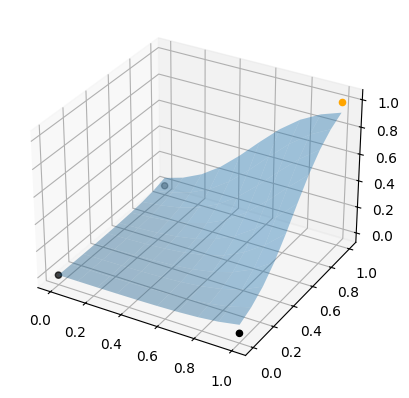

In [36]:
# sigmoid with numpy
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))

ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 0, 1], [0, 1, 0], [0, 0, 0], color='black')
ax.scatter([1], [1], [1], color='orange')

# create grid
x = np.linspace(0, 1, 10)
y = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, y)

# sig(z = w1*x + w2*y + b)
Z = np_sigmoid(perceptron.w1 * X + perceptron.w2 * Y + perceptron.b)

ax.plot_surface(X, Y, Z, alpha=0.4)
plt.show()

Now our perceptron is modeling a curved surface instead of a plane. This can better adapt the model to the data.

## Multi Layer Perceptron

Since our perceptron is modeling well the AND function, let's test it in another logical function the XOR function.

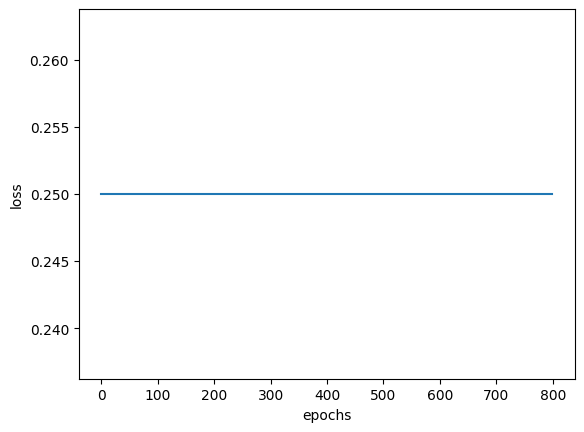

In [37]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 1, 1, 0]

a = 0.5

perceptron = Perceptron()

train(perceptron, x, y, a, 800)

Now the loss is not going down, whats going on? Let's see the outputs of the model.

In [38]:
print(perceptron.w1, perceptron.w2, perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0.0 0.0 0.0
0 0 -> 0.5000
0 1 -> 0.5000
1 0 -> 0.5000
1 1 -> 0.5000


The outputs are all the same, the model is not learning at all. The AND function is a class of decision problems that have the property of linear separability. That means that we can draw a line that divides all classes of points in one side and the other class in the other side. Since our perceptron acts as a classifier in this example (correctly labeling a set of points) this line learned by the model is called decision boundary.

Let's see this in this next plot:

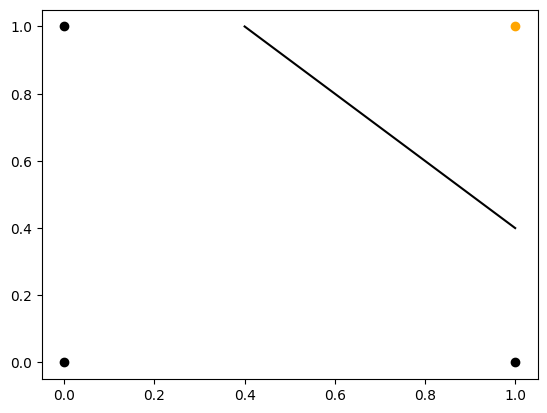

In [39]:
# the pairs that have output = 0
plt.scatter([0, 0, 1], [0, 1, 0], color='black', zorder=1)
# the pair that have the output = 1
plt.scatter([1], [1], color='orange', zorder=1)

# the line
plt.plot([0.4, 1], [1, 0.4], color='black', zorder=2)
plt.show()

For the XOR function, we need more than one line to correctly classify our points.

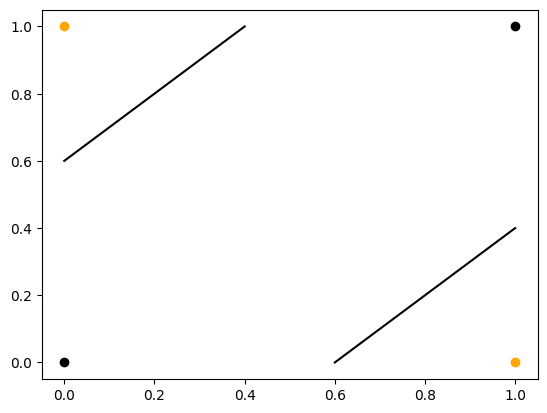

In [40]:
# the pairs that have output = 0
plt.scatter([0, 1], [0, 1], color='black', zorder=1)
# the pair that have the output = 1
plt.scatter([0, 1], [1, 0], color='orange', zorder=1)

# we need two lines to separate the data
plt.plot([0.0, 0.4], [0.6, 1.0], color='black', zorder=2)
plt.plot([0.6, 1], [0.0, 0.4], color='black', zorder=2)

plt.show()

Since our perceptron can only model a line, we need to improve its capacity of representation to deal with the XOR function. To solve this we can compose multiple functions together to approximate any continuous function. This is called Universal approximation theorem. Again with inspiration from the brain, the neurons don't work alone but they are combined as input to a neuron which output will also serve as input to another group of neurons.

To simplify this abstraction let's first consider the way our perceptron works. The output of our perceptron is defined as:

$$ o = \sigma(w_1x_1 + w2_x2 + b) $$

If we treat our input as a vector $ \vec{X} = [x_1, x_2] $ and treat our perceptron weights also as a vector $ \vec{W} = [w_1, w_2] $. Then, our output can be represented as the dot product of those vectors, added by the bias and then feed to the activation function:

$$ o = \sigma(\vec{X} \cdot \vec{W}^T + b) $$

Let's see one example:

In [41]:
# input matrix
x = [0, 1]
# weight matrix
w = [1, 1]

# our bias
b = [0]

o = [w[0] * x[0] + w[1] * x[1] + b[0]]
print(o)

[1]


To make it easier for us lets define a matrix multiplication function:

In [42]:
def matmul(a, b):
    mat = [[0 for _ in range(len(b[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(b[0])):
            for k in range(len(a[0])):
                mat[i][j] += a[i][k] * b[k][j]

    return mat

Now we can just apply the matrix multiplication in the input and the weights:

In [43]:
# 1 x 2 input vector
x = [[0, 1]]

# 2 x 1 weight vector
# representing as a column vector so we don't need transposition
w = [[1],
      [1]]

print(matmul(x, w))

[[1]]


We can define also a matrix addition for our bias:

In [44]:
def add(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] + b[i][j]

    return mat

In [45]:
# 1 x 2 input vector
x = [[0, 1]]

# 2 x 1 weight vector
# representing as a column vector so we don't need transposition
w = [[1],
     [1]]

# 1 x 1 bias
b = [[1]]


print(add(matmul(x, w), b))

[[2]]


The advantage of this approach is that now the code is the same regardless of the shape of our vectors. This will help us in creating networks with arbitrary weights.

We can also put everything into a class to easy use as those linear transformations will be frequent.

In [46]:
class Linear:

    # constructor with input and output sizes
    def __init__(self, inp, out):
        # weights
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        # bias
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        # w_1x_1 + ... + w_nx_n + b
        return add(matmul(x, self.w), self.b)


x1 = [[0, 1]]
linear = Linear(2, 1)
print(linear.forward(x1))

[[0]]


Now if we need to create multiple lines this becomes easier.

In [47]:
linear1 = Linear(2, 1)
linear2 = Linear(2, 1)

x1 = [[0, 1]]

h1 = linear1.forward(x1)
h2 = linear2.forward(x1)

print(h1, h2)

[[0]] [[0]]


Another improvement is that two lines with one output is the same as one line with two outputs.


In [48]:
linear1 = Linear(2, 2)

h1 = linear1.forward(x1)

print(h1)

[[0, 0]]


Then we can stack multiple linear layers to combine then and produce a single output.

In [49]:
linear1 = Linear(2, 2)
linear2 = Linear(2, 1)

h1 = linear1.forward(x1)

h2 = linear2.forward(h1)

print(h2)

[[0]]


However, a linear transformation inside a linear transformation is still a linear transformation:

$$ h_1 = w_1x_1 + w_2x_2 + b $$

$$ h_2 = w_3h_1 + b $$

$$ h_2 = w_3(w_1x_1 + w_2x_2 + b) + b $$

$$ h_2 = w_3w_1x_1 + w_3w_2x_2 + (w_3b + b) $$

Adding those $w_3b + b$ is the same as just having another bias $b_3$.

$$ h_2 = w_3w_1x_1 + w_3w_2x_2 + b_3 $$

This is another reason of why we need the activation function is to achieve the non-linearity needed to build the universal function approximate.

For this, we need to apply the sigmoid function in each value of our vector.

In [50]:
# element-wise sigmoid
def sigmoid(x):
    mat = [[0 for _ in range(len(x[0]))] for _ in range(len(x))]

    for i in range(len(x)):
        for j in range(len(x[0])):
            mat[i][j] = 1 / (1 + math.exp(-x[i][j]))

    return mat

linear1 = Linear(2, 2)
linear2 = Linear(2, 1)

h1 = sigmoid(linear1.forward(x1))
h2 = sigmoid(linear2.forward(h1))

print(h2)

[[0.5]]


Now we have all ingredients to implement our model. Since our input is a matrx, we can also pass the whole dataset as input and compute its outputs in one pass. But to do this, since our bias is a single value we need to repeat it for each new pair in the input. This operation is called broadcasting.

We can also override the __call__ method and use our linear layer as a function.

In [51]:
class Linear:

    def __init__(self, inp, out):
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    # calling the linear as a function
    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

linear = Linear(2, 2)
# the whole dataset as input
# calling with forward
h1 = linear.forward(x)
print(h1)

# or as a function
h1 = linear(x)
print(h1)

[[0, 0], [0, 0], [0, 0], [0, 0]]
[[0, 0], [0, 0], [0, 0], [0, 0]]


To compute our gradients in the backward pass we need to implement the other operations to the vectors.

In [52]:
def sub(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] - b[i][j]

    return mat

def pow(a, n):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] ** n

    return mat

def mul_s(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b

    return mat

def mul(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b[i][j]

    return mat

Now the same perceptron but with the linear layer and the vector backward.

In [53]:
class Perceptron:

    def __init__(self, inp, out):
        self.linear1 = Linear(inp, out)

    def forward(self, x):
        return sigmoid(self.linear1(x))

    def backward(self, x, y):
        l1 = self.linear1(x)
        o = sigmoid(l1)

        de = mul_s(sub(y, o), 2)
        do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

        db = mul(de, do)

        dw = mul([q * len(x[0]) for q in db], x)

        return [[sum([q[i] for q in dw])] for i in range(len(dw[0]))], [[sum([q[0] for q in db])]]

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

We need to update also the train function

In [54]:
def train(perceptron, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = perceptron(x)

        error_sqr = sum(q[0] for q in pow(sub(y, o), 2)) / len(y)

        lh.append(error_sqr)

        dw, db = perceptron.backward(x, y)

        perceptron.linear1.w = sub(perceptron.linear1.w, mul_s(dw, a))
        perceptron.linear1.b = sub(perceptron.linear1.b, mul_s(db, a))

    plt.plot(lh)
    plt.show()

Now let's test if it works.

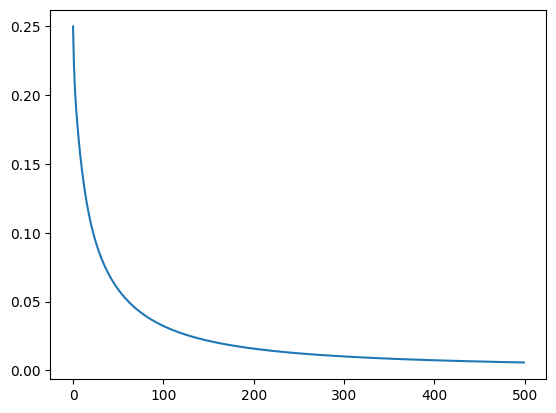

In [55]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [[0], [0], [0], [1]]

a = 0.5

perceptron = Perceptron(2, 1)

train(perceptron, x, y, a, 500)

In [56]:
print(perceptron.linear1.w, perceptron.linear1.b)

for x1, y1 in zip(x, y):
    o = perceptron([x1])
    print(f'{x1} -> {o[0]}')

[[4.646713304738055], [4.646713304738055]] [[-7.067441931349512]]
(0, 0) -> [0.0008516848626281008]
(0, 1) -> [0.08160563105078451]
(1, 0) -> [0.08160563105078451]
(1, 1) -> [0.902558796204585]


Works as expected.

Now to deal with the XOR function we need to compose functions or stack multiple linear layers. This new model is called Multi-Layer Perceptron. It is similar to the Perceptron but with more layers:

In [59]:
class MLP:

    def __init__(self, inp, out):
        # first layer outputs 4 values that will be input to the next layer
        self.linear1 = Linear(inp, 4)
        # (w1, w2, w3, w4) + bias
        self.linear2 = Linear(4, out)

    def forward(self, x):
        # compute the output of the first layer
        h1 = sigmoid(self.linear1(x))
        # now the output of the first layer is the input of the last layer
        return sigmoid(self.linear2(h1))

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

We run it in the same way we run the Perceptron:

In [60]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

o = mlp(x)

print(o)

[[0.5], [0.5], [0.5], [0.5]]


Now the hard work: computing the backward pass. We already know how to compute the gradients of the last layer since they are the same as the previous perceptron. To propagate those gradients to the next layer we just keep following the chain rule and multiplying the gradients from previous layers to those local gradients of the last layer:

While our weights are inside only one matrix, lets consider them as two different lines and lets label each sigmoid function to simplify our computing:

$$ h_1 = \sigma_1(w_1x_1 + w_2x_2 + b_1) $$
$$ h_2 = \sigma_2(w_3x_1 + w_4x_2 + b_2) $$

Now the second layer:

$$ h_3 = w_5h_1 + w_6h_2 + b_3 $$
$$ o = \sigma_3(h_3) $$

And finally our loss:

$$ loss = (y - o) ^ 2 $$

Let's start computing our gradients:

$$ \frac{dloss}{do} = 2(y - o) $$

$$ \frac{do}{d\sigma_3} = - (\sigma(h_3) \cdot (1 - \sigma(h_3)) $$

And then the local gradient of the $w_5$ with respect to $\sigma_3$:

$$ \frac{\sigma_3}{dw_5} = h_1 $$

Now the gradient with respect to the loss is just the multiple of the previous local gradients:

$$ \frac{dloss}{dw_5} = \frac{dloss}{do} \cdot \frac{do}{d\sigma_3} \cdot * \frac{d\sigma_3}{dw_5} $$

Substituting it:

$$ \frac{dloss}{dw_5} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) \cdot h_1 $$

Now for $w_6$ and $b_3$:

$$ \frac{dloss}{dw_6} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) \cdot h_2 $$

$$ \frac{dloss}{db_3} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) $$

Continuing to compute $dw_1$:

$$ \frac{dh_3}{d\sigma_1} = w_5 \cdot \sigma(h_1) \cdot (1 - \sigma(h_1)) $$

$$ \frac{d\sigma_1}{dw_1} = x_1 $$

The other weights follow the same pattern. Let's implement them in code:

In [64]:


def backward(self, x, y):
    l1 = self.linear1(x)
    h1 = sigmoid(l1)
    l2 = self.linear2(h1)
    o = sigmoid(l2)

    # loss gradient
    d_loss = mul_s(sub(y, o), 2)

    # output gradient
    do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

    # second layer bias gradient
    db2 = mul(d_loss, do)
    # second layer weight gradient
    dw2 = mul([q * len(h1[0]) for q in db2], h1)

    # second layer gradient
    dl2 = mul([q * len(self.linear2.w) for q in db2], [[q[0] for q in self.linear2.w] for _ in db2])

    # first layer bias gradient
    db1 = mul(dl2, mul(h1, sub([[1] * len(h1[0]) for _ in h1], h1)))

    # broadcast second layer gradient
    bd1 = [[q] * len(x[0]) for q in db1]

    # broadcast input
    bx = [[[w] * len(bd1[0][0]) for w in q] for q in x]

    # first layer weight gradient
    dw1 = [mul(q, w) for q, w in zip(bd1, bx)]

    # now we average the gradients
    gb2 = [[sum(q[0] for q in db2)]]
    gw2 = [[sum([d[i] for d in dw2])] for i in range(len(dw2[0]))]
    gb1 = [[sum([d[i] for d in db1]) for i in range(len(db1[0]))]]
    gw1 = [[sum(e[q][j] for e in dw1) for j in range(len(dw1[0][0]))] for q in range(len(dw1[0]))]

    return gw1, gb1, gw2, gb2

MLP.backward = backward

Now update the training function to update all weights:

In [65]:
def train(model, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = model(x)
        lh.append(sum([x[0] for x in pow(sub(y, o), 2)]) / len(y))

        jw1, jb1, jw2, jb2 = model.backward(x, y)

        model.linear2.b = sub(model.linear2.b, mul_s(jb2, a))
        model.linear2.w = sub(model.linear2.w, mul_s(jw2, a))
        model.linear1.b = sub(model.linear1.b, mul_s(jb1, a))
        model.linear1.w = sub(model.linear1.w, mul_s(jw1, a))

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('error')
    plt.show()

Now we can train and see if it works:

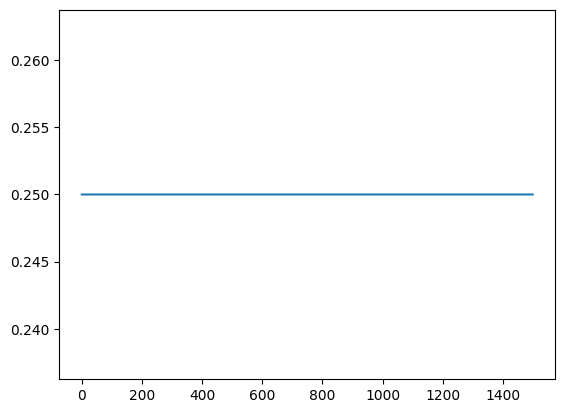

In [66]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 1500)

Strange, our model is not learning. But our code is correct what can be happening?

Let's see the model output:

In [67]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.5]
[0, 1] -> [0.5]
[1, 0] -> [0.5]
[1, 1] -> [0.5]


Debugging neural models is a hard task because it won't tell us what is wrong in the code. We need to search for expected behaviour and try to find the source of the problem.

Let's check the gradients of a new model:

In [69]:
mlp = MLP(2, 1)

jw1, jb1, jw2, jb2 = mlp.backward(x, y)

print(jw1, jb1, jw2, jb2)

[[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]] [[0.0, 0.0, 0.0, 0.0]] [[0.0], [0.0], [0.0], [0.0]] [[0.0]]


All gradients are 0. We found the path to solve our problem. Zero gradients means that there is no signal to update our weights.

Let's compute the gradients of the output to see if we can find the problem:

In [70]:
# local gradient of loss
de = mul_s(sub(y, o), 2)

# local gradient of output
do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

# gradient of the loss with respect the the output
db2 = mul(de, do)
print(db2)

[[0.25], [-0.25], [-0.25], [0.25]]


The gradients are not zero. But look at them. At the last step when we average those gradients they will cancel out and become zero.

Let's check this:

In [72]:
print(sum(q[0] for q in db2))

0.0


The problem in this case is that because of the nature of the data and the output of our model, the average of the gradients are zero. One way to simply solve this problem is by introducing small variations in the initial gradient to give us the signal needed to the learning of our model.

To introduce those variations, instead of initializing our weights and biases in the linear layers with 0 we can choose a random value to start.

In this way the probability of having zero gradients at the start due to the nature of data is very low.

In [73]:
class Linear:

    def __init__(self, inp, out):
        # random initialization of our weights
        self.w = [[random.random() for _ in range(out)] for _ in range(inp)]
        # random initialization of our biases
        self.b = [[random.random() for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

Testing again:

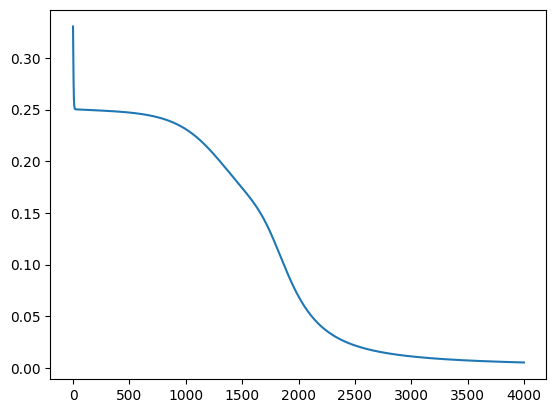

In [74]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 4000)

Now it works. Let's check also the model outputs.

In [75]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.03267322932871577]
[0, 1] -> [0.9287246761240893]
[1, 0] -> [0.9245208156682658]
[1, 1] -> [0.09266185313639744]


The outputs are what we expect. We can check also the surface learned by our model.

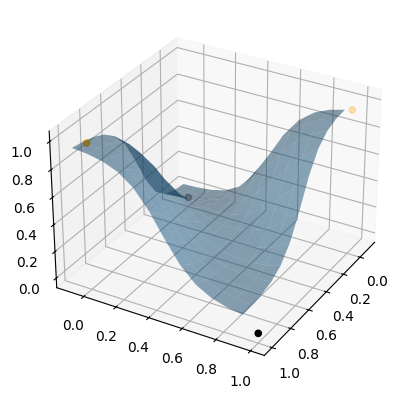

In [94]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 1], [0, 1], [0, 0], color='black')
ax.scatter([1, 0], [0, 1], [1, 1], color='orange')

# create grid
grid = []
for x1 in range(-1, 11):
    for x2 in range(-1, 11):
        grid.append([x1 / 10, x2 / 11])

o = [q[0] for q in mlp(grid)]

shape = (12, 12)
X = np.array([q[0] for q in grid]).reshape(shape)
Y = np.array([q[1] for q in grid]).reshape(shape)
Z = np.array(o).reshape(shape)

ax.plot_surface(X, Y, Z, alpha=0.5)
ax.view_init(elev=30, azim=30)
plt.show()

Our model fits our data by creating a valley with two peaks where the points are 1. All the learning with those neural model are about modeling the right surface to fit our data.

Let's test again with the logical function NAND.

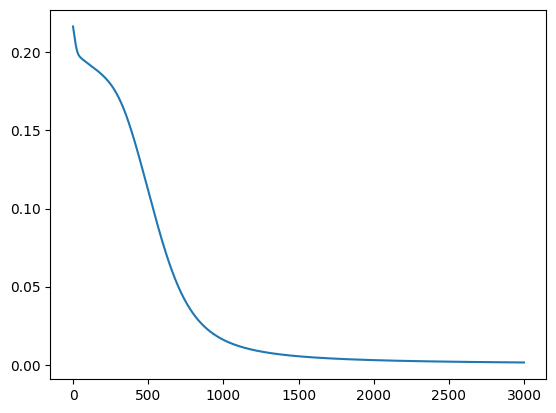

In [96]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[1], [1], [1], [0]]

train(mlp, x, y, 0.1, 3000)

In [97]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.9985765870616491]
[0, 1] -> [0.9634464778351025]
[1, 0] -> [0.961235359381563]
[1, 1] -> [0.053057358241801945]


Works as well with the NAND gate. This one is an interesting logical function because modern CPUs are all built from combinations of multiple NAND as we can build the other logic functions using only NAND gates.

Question to the reader:

Are neural networks turing-complete since we can approximate a NAND gate with them?

# Autograd



https://youtu.be/VMj-3S1tku0?si=uil5F1BfkH0MwoB0

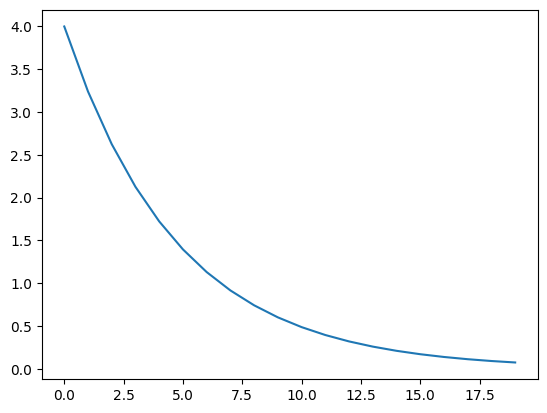

4.756846690818861


In [50]:
class Value:

    def __init__(self, data, children=(), local_grad=()):
        self.data = data
        self.grad = 0
        self.children = children
        self.local_grad = local_grad

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, children=(self, other), local_grad=(1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, children=(self, other), local_grad=(other.data, self.data))

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __pow__(self, power, modulo=None):
        return Value(self.data ** power, children=(self,), local_grad=(power * self.data ** (power - 1),))

    def __repr__(self):
        return f'Value({self.data}, {self.grad})'

    # only acyclic graphs
    def backward(self, grad=1):
        self.grad = grad

        for c, lg in zip(self.children, self.local_grad):
            c.backward(grad * lg)

w = Value(1)
b = Value(1)

x = 2
y = 5
a = 0.01

lh = []
for _ in range(20):
    o = w * x + b
    error_sqr = (y - o) ** 2

    error_sqr.backward()

    lh.append(error_sqr.data)

    w.data -= 0.01 * w.grad
    b.data -= 0.01 * b.grad

plt.plot(lh)
plt.show()

print(w.data * x + b.data)

In [51]:
import torch

In [52]:
a = torch.Tensor([1, 2])
print(a + 2)

tensor([3., 4.])


In [53]:
import time

a1 = [[i for i in range(10_000_000)]]
a2 = [[i for i in range(10_000_000)]]

start = time.time()
add(a1, a2)
print(time.time() - start)

t1 = torch.Tensor(a1)
t2 = torch.Tensor(a2)

start = time.time()
t3 = t1 + t2
print(time.time() - start)


0.7434089183807373
0.006547451019287109


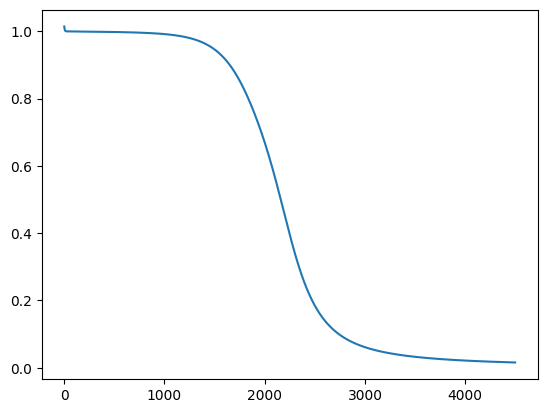

In [54]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, inp, out):
        super().__init__()

        self.l1 = nn.Linear(inp, 4)
        self.l2 = nn.Linear(4, out)

    def forward(self, x):
        h1 = torch.sigmoid(self.l1(x))
        return torch.sigmoid(self.l2(h1))




def train(model, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = model(x)

        e = (y - o) ** 2

        loss = e.sum()
        loss.backward()

        lh.append(loss.item())


        for p in model.parameters():
            p.data -= a * p.grad
            p.grad.zero_()

    plt.plot(lh)
    plt.show()

mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

train(mlp, x, y, 0.1, 4500)

In [55]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

tensor([0., 0.]) -> tensor([0.0351], grad_fn=<UnbindBackward0>)
tensor([0., 1.]) -> tensor([0.9407], grad_fn=<UnbindBackward0>)
tensor([1., 0.]) -> tensor([0.9338], grad_fn=<UnbindBackward0>)
tensor([1., 1.]) -> tensor([0.0795], grad_fn=<UnbindBackward0>)


In [56]:
with torch.no_grad():
    o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

tensor([0., 0.]) -> tensor([0.0351])
tensor([0., 1.]) -> tensor([0.9407])
tensor([1., 0.]) -> tensor([0.9338])
tensor([1., 1.]) -> tensor([0.0795])


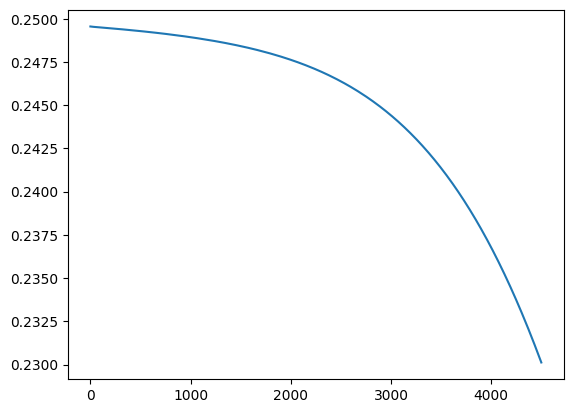

In [57]:
def train(model, x, y, lr, epochs):
    crit = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    lh = []
    for _ in range(epochs):
        optimizer.zero_grad()
        o = model(x)

        e = crit(y, o)

        loss = e.sum()
        loss.backward()

        lh.append(loss.item())

        optimizer.step()

    plt.plot(lh)
    plt.show()


mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

train(mlp, x, y, 0.1, 4500)

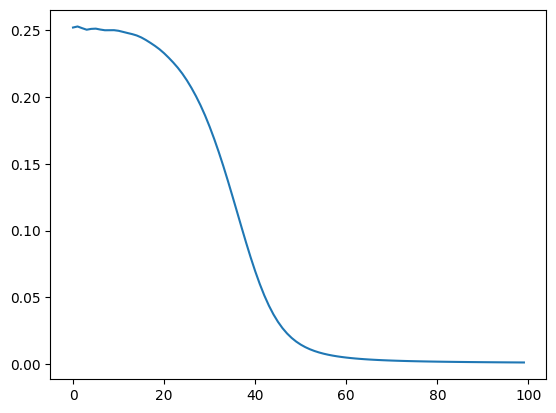

In [58]:
def train(model, x, y, lr, epochs):
    crit = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in range(epochs):
        optimizer.zero_grad()
        o = model(x)

        e = crit(y, o)

        loss = e.sum()
        loss.backward()

        lh.append(loss.item())

        optimizer.step()

    plt.plot(lh)
    plt.show()


mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

train(mlp, x, y, 0.1, 100)

In [59]:
from sklearn.datasets import load_iris

In [60]:
iris = load_iris()

In [61]:
data = iris['data']
targets = iris['target']

In [62]:
x = torch.Tensor(data)
y = torch.Tensor(targets)

# shuffle data and split into train and test
perm = torch.randperm(len(x))
x = x[perm]
y = y[perm]

train_size = int(0.8 * len(x))
x_train = x[:train_size]
y_train = y[:train_size]
x_test = x[train_size:]
y_test = y[train_size:]

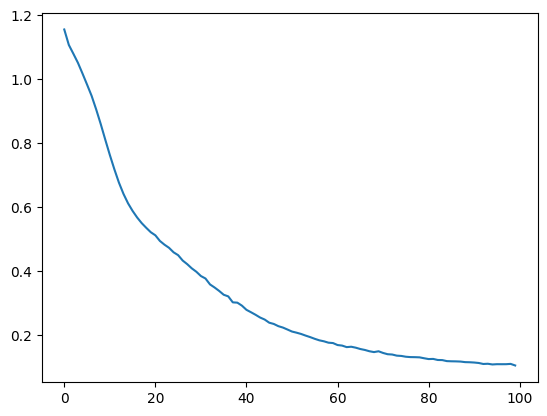

In [63]:
from torch.utils.data import DataLoader, TensorDataset

class Model(nn.Module):
    def __init__(self, inp, out):
        super().__init__()

        self.l1 = nn.Linear(inp, 4)
        self.l2 = nn.Linear(4, out)

    def forward(self, x):
        h1 = torch.sigmoid(self.l1(x))
        return torch.log_softmax(self.l2(h1), dim=-1)






def train(model, data, lr, epochs):
    crit = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in range(epochs):
        el = []
        for x, y in DataLoader(data, batch_size=16, shuffle=True):
            optimizer.zero_grad()
            o = model(x)

            e = crit(o, y)

            loss = e.sum()
            loss.backward()
            el.extend(loss.item() for _ in range(len(x)))

            optimizer.step()

        lh.append(sum(el) / len(el))

    plt.plot(lh)
    plt.show()


model = Model(4, 3)

train(model, TensorDataset(x_train, y_train.long()), 0.01, 100)

In [64]:
def test(model, data):
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in DataLoader(data, batch_size=16, shuffle=False):
            o = model(x)
            pred = o.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += len(x)

    print(f'Accuracy: {correct / total:.4f}')


test(model, TensorDataset(x_test, y_test.long()))

Accuracy: 1.0000


In [65]:
from torchvision.datasets.mnist import MNIST

data = MNIST(root='./data', download=True)

In [66]:
print(len(data))

60000


In [67]:
import numpy as np

si = torch.randperm(len(data))
data = [data[i] for i in si]
train_data = [(torch.from_numpy(np.array(x)).float(), torch.LongTensor([y])) for x, y in data[:50_000]]
tx, ty = zip(*train_data)
tds = TensorDataset(torch.stack(tx), torch.cat(ty))
test_data = [(torch.from_numpy(np.array(x)).float(), torch.LongTensor([y])) for x, y in data[50_000:]]
tx, ty = zip(*test_data)
test_ds = TensorDataset(torch.stack(tx), torch.cat(ty))

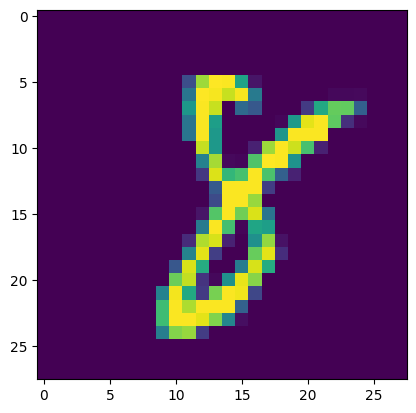

In [68]:
plt.imshow(train_data[4][0])
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

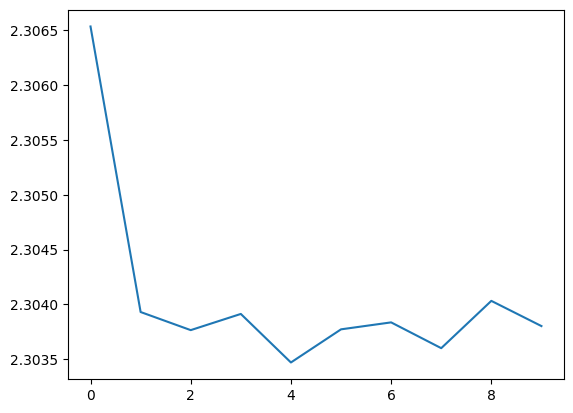

In [69]:
from tqdm.auto import tqdm

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.seq(x)


model = Model()

def train(model, data, lr, epochs):
    crit = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in tqdm(range(epochs)):
        el = []
        for x, y in DataLoader(data, batch_size=8, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, y)
            loss.backward()
            el.append(loss.item())

            optimizer.step()

        lh.append(sum(el) / len(el))

    plt.plot(lh)
    plt.show()


train(model, tds, 0.01, 10)

In [70]:
def test(model, data):
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in DataLoader(data, batch_size=16, shuffle=False):
            o = model(x)
            pred = o.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += len(x)

    print(f'Accuracy: {correct / total:.4f}')

test(model, test_ds)

Accuracy: 0.1089


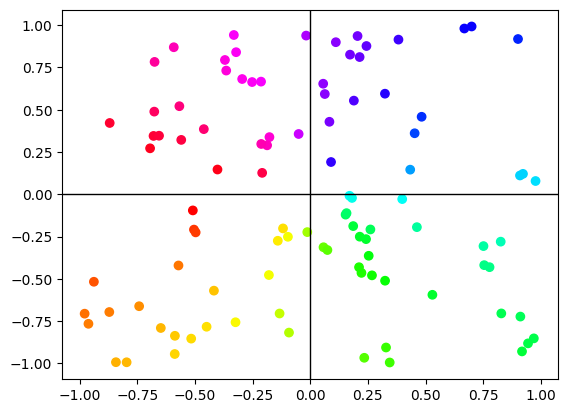

In [76]:
rx = torch.rand((100, 1)) * 2 - 1.0
ry = torch.rand((100, 1)) * 2 - 1.0

colors = torch.atan2(ry, rx) / (2 * math.pi) + 0.5

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

plt.scatter(rx, ry, c=colors, cmap='hsv')

plt.show()

In [94]:
ln1 = nn.Linear(2, 2)

with torch.no_grad():
    o = ln1(torch.cat([rx, ry], dim=-1))

nrx = o[:, 0]
nry = o[:, 1]

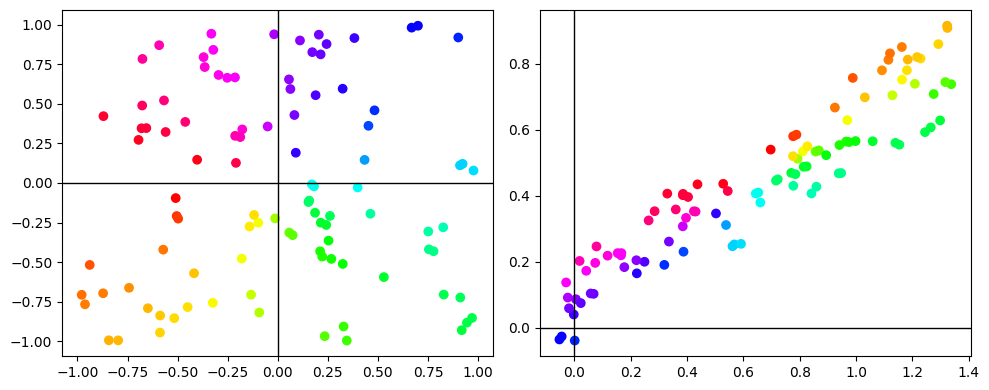

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].axhline(0, color='black', lw=1)
ax[0].axvline(0, color='black', lw=1)

ax[0].scatter(rx, ry, c=colors, cmap='hsv')

ax[1].axhline(0, color='black', lw=1)
ax[1].axvline(0, color='black', lw=1)

ax[1].scatter(nrx, nry, c=colors, cmap='hsv')

fig.tight_layout()
plt.show()

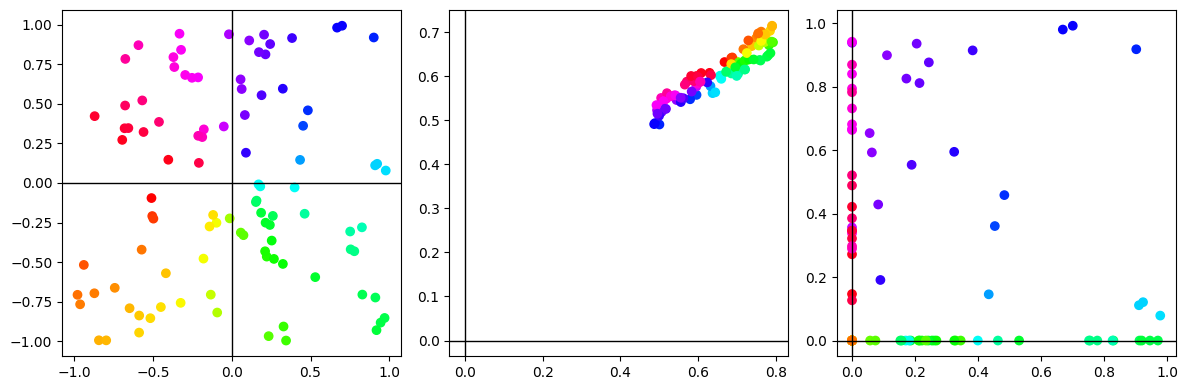

In [96]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].axhline(0, color='black', lw=1)
ax[0].axvline(0, color='black', lw=1)

ax[0].scatter(rx, ry, c=colors, cmap='hsv')

ax[1].axhline(0, color='black', lw=1)
ax[1].axvline(0, color='black', lw=1)

ax[1].scatter(torch.sigmoid(nrx), torch.sigmoid(nry), c=colors, cmap='hsv')

ax[2].axhline(0, color='black', lw=1)
ax[2].axvline(0, color='black', lw=1)

o = torch.relu(torch.cat([rx, ry], dim=-1))

nrx = o[:, 0]
nry = o[:, 1]

ax[2].scatter(nrx, nry, c=colors, cmap='hsv')

fig.tight_layout()
plt.show()

https://www.youtube.com/watch?v=-at7SLoVK_I&t=384s

  0%|          | 0/10 [00:00<?, ?it/s]

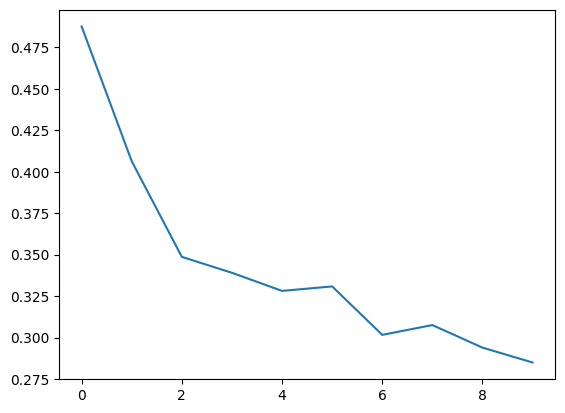

In [98]:
model = Model()

tx, ty = zip(*train_data)
tx = torch.stack(tx)
ty = torch.cat(ty)
tx = (tx - tx.mean()) / (tx.std() + 1e-8)
tds = TensorDataset(tx, ty)

train(model, tds, 0.01, 10)

In [99]:
test(model, test_ds)

Accuracy: 0.7673


  0%|          | 0/10 [00:00<?, ?it/s]

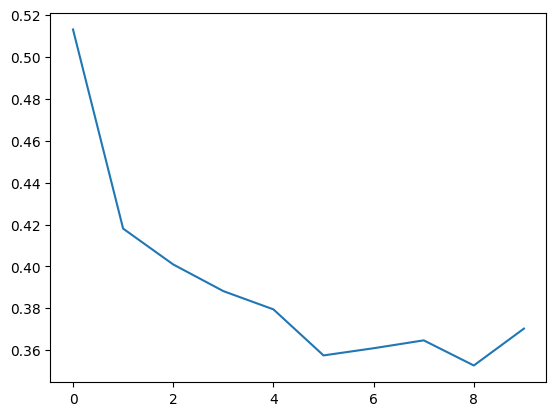

In [104]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.seq(x)

model = Model()
train(model, tds, 0.006, 10)

In [106]:
model.eval()

test(model, test_ds)

Accuracy: 0.8323


  0%|          | 0/10 [00:00<?, ?it/s]

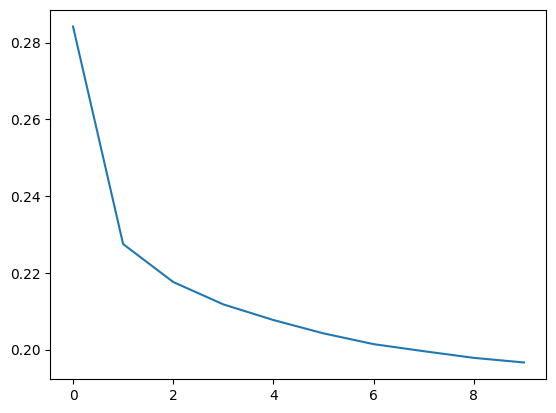

In [112]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        self.dec = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 28 * 28),
            nn.Unflatten(1, (28, 28))
        )

    def forward(self, x):
        h = self.enc(x)
        return self.dec(h)

def train(model, data, lr, epochs):
    crit = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in tqdm(range(epochs)):
        el = []
        for x, _ in DataLoader(data, batch_size=8, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, x)
            loss.backward()
            el.append(loss.item())

            optimizer.step()

        lh.append(sum(el) / len(el))

    plt.plot(lh)
    plt.show()

model = Model()
train(model, tds, 0.0006, 10)

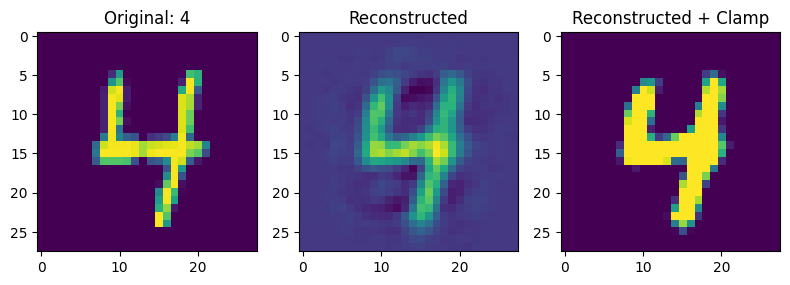

In [119]:
x, y = tds[0]

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(x)
ax[0].set_title(f'Original: {y.item()}')

with torch.no_grad():
    o = model(x.unsqueeze(0))[0]
ax[1].imshow(o)
ax[1].set_title('Reconstructed')

ax[2].imshow(torch.clamp(o, 0, 1))
ax[2].set_title('Reconstructed + Clamp')

fig.tight_layout()
plt.show()